# EMRI_wf_JAX

Build the full EMRI waveform with a direct-mode-sum implementation.

## Notebook structure

**Setup** — trajectory, amplitude generation, and mode selection.

---

**Alternative Implementations** — three earlier builders, kept for reference:

| Function | Strategy | Materialises `(n_t_dense, n_m)`? | Notes |
|---|---|---|---|
| `jax_direct_mode_sum` | vmap over a *batch of EMRIs* | Yes — must be provided as input | Good for many short EMRIs on the same grid |
| `fused_waveform` | `jax.lax.scan` over *time chunks* | No — only `(chunk, n_m)` at once | JIT shapes tied to `chunk_size`; slow to compile for many chunks |
| `interpolator` | Upsample all modes in one pass | Yes — `(n_t_dense, n_m)` | Utility helper, not a standalone waveform builder |

---

**Primary Implementation** — `Interp_and_modesum_WFbuilder`.

Streams over *mode batches* on the **full** dense time grid. Per batch: a
single fused kernel interpolates the modes, computes **one shared**
`exp(−i·phase)`, and reduces via two GEMVs. The `(n_t_dense, n_m)` array
is never materialised. **Use this for production.**

$$
h(t)=\sum_{\ell m k n}\!\Big[\,Y_{\ell m}^{+}\,A_{\ell m k n}\,
e^{-i(m\Phi_\phi+k\Phi_\theta+n\Phi_r)}\Big]
\;+\;\sum_{\ell,m>0,k,n}\!\Big[(-1)^{\ell}\,
Y_{\ell m}^{-}\,A^{\ast}_{\ell m k n}\,
e^{+i(m\Phi_\phi+k\Phi_\theta+n\Phi_r)}\Big]
$$


In [1]:
import os
idx = 1
os.environ["CUDA_VISIBLE_DEVICES"] = str(idx)
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["FEW_DATA_DIR"] = "/home/fedefant/.local/share/few/v2.0.0/download"


In [2]:
import time
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
#import cupy
jax.config.update("jax_enable_x64", True)

import psutil

import few
from few.trajectory.ode.flux import KerrEccEqFlux
from few.trajectory.inspiral import EMRIInspiral
from few.utils.geodesic import get_separatrix
from few.summation.directmodesum import DirectModeSum
from few.waveform import GenerateEMRIWaveform
from few.waveform.waveform import FastKerrEccentricEquatorialFlux
from few.utils.constants import MTSUN_SI, YRSID_SI
from few.utils.utility import get_mismatch

Gpc      = few.utils.constants.Gpc
MRSUN_SI = few.utils.constants.MRSUN_SI

cupy = None
if cupy is not None:
    xp = cupy
else:
    xp = np

def report_mem(tag):
    proc = psutil.Process()
    rss_gb = proc.memory_info().rss / 1024**3
    msg = [f"{tag} | CPU RSS: {rss_gb:.2f} GB"]
    if cupy is not None:
        try:
            free, total = cupy.cuda.runtime.memGetInfo()
            msg.append(f"GPU: {((total-free)/1024**3):.2f} GB used / {total/1024**3:.2f} GB total")
        except Exception as exc:
            msg.append(f"GPU: unavailable ({exc})")
    print(" | ".join(msg))

In [3]:
# JAX GPU preallocation diagnostic
report_mem("before jax warmup")
print("JAX backend:", jax.default_backend())
print("JAX devices:", jax.devices())
_warm = jnp.ones((1,))
_ = _warm.block_until_ready()
report_mem("after jax warmup")

before jax warmup | CPU RSS: 0.30 GB
JAX backend: gpu
JAX devices: [CudaDevice(id=0)]
after jax warmup | CPU RSS: 0.74 GB


In [10]:
cfg = few.get_config_setter(reset=True)
cfg.set_log_level("info")

# FastKerrEccentricEquatorialFlux bundles trajectory, AmpInterpKerrEccEq,
# GetYlms, ModeSelector, and InterpolatedModeSum. We reuse its components
# directly so the manual pipeline is guaranteed to use the same setup.

report_mem("before model init")
if cupy is not None:
    try:
        cupy.get_default_memory_pool().free_all_blocks()
    except Exception:
        pass

try:
    model = FastKerrEccentricEquatorialFlux(force_backend='gpu')
    report_mem("after model init (gpu)")
except Exception as exc:
    print(f"GPU model init failed: {exc}")
    print("Falling back to CPU backend for model init.")
    model = FastKerrEccentricEquatorialFlux(force_backend='cpu')
    report_mem("after model init (cpu)")

few_traj  = model.inspiral_generator

# The mode threshold determines how many modes we are going to have
mode_selection_threshold = 1e-5
mode_selector_kwargs = dict(
    mode_selection_threshold = mode_selection_threshold,
    include_minus_mkn        = True,
)

before model init | CPU RSS: 3.81 GB
after model init (gpu) | CPU RSS: 3.80 GB


---

## Primary Implementation

**`Interp_and_modesum_WFbuilder`** -- recommended for all production runs.

### Three versions (earlier ones commented out)

| Version | Amplitude interp | Phase interp | Exp cost | Notes |
|---------|-----------------|-------------|----------|-------|
| v1 | linear | linear | n_m x n_t per batch | baseline |
| v2 | linear | linear | ~20 total | factorised exp |
| **v3** | **cubic spline** | **cubic spline** | **~20 total** | **matches FEW accuracy** |

### v3 algorithm

1. **`_fit_spline`** -- fit not-a-knot cubic splines to the 67 sparse trajectory
   points for all mode amplitudes `(4, 66, n_m)` and all 3 phases `(4, 66, 3)`. Negligible CPU cost.
2. **`_bracket`** -- compute bracket indices `inds` and time offset `dx` for the full `t_dense` **once**.
3. **`_eval_cubic`** -- evaluate the 3 phase splines at `t_dense` via Horner's method -> `(n_t_dense, 3)`.
4. **Exp factorisation** -- precompute `E_phi`, `E_theta`, `E_r` tables (~20 exp calls).
5. For each mode batch of size `sum_batch_size`:
   - Evaluate amplitude spline batch via Horner: gathers from tiny `(4, 66, batch)` arrays.
   - Assemble phase factor: `E = (E_phi[m_inv] * E_theta[k_inv] * E_r[n_inv]).T` -- no exp.
   - `T = teuk_dense * E`, then `w1 = T @ ylm_pos`, `w2 = conj(T) @ coeff_neg`.
   - Accumulate; discard `teuk_dense`.

**Accuracy:** cubic splines match FEW's `InterpolatedModeSum` (same boundary conditions).
The mismatch at fine `dt` that appeared with linear interpolation is eliminated.

**Speed:** Horner gathers from `(66, batch)` source arrays (~200 KB) -- XLA can fuse the four gather+multiply steps without materialising intermediate buffers.
The exp factorisation from v2 is retained.

In [17]:
# Mode-batched interp + direct mode sum.
# v3: cubic spline interp (amplitudes AND phases) + factorised exp [ACTIVE]
#
# v3 matches FEW's InterpolatedModeSum accuracy (not-a-knot cubic splines)
# while keeping the exp-factorisation speedup from v2.

from scipy.interpolate import CubicSpline as _CubicSpline

def _fit_spline(t_sparse_np, y_sparse_np):
    """Fit a not-a-knot cubic spline and return scipy's (4, n-1, ...) coefficient array."""
    cs = _CubicSpline(t_sparse_np, y_sparse_np)
    return jnp.asarray(cs.c)   # (4, n_sparse-1, *y_shape[1:])


@jax.jit
def _bracket(t_traj, t_dense):
    """Bracket indices and normalised weights: inds, w = (t-t_i)/(t_{i+1}-t_i)."""
    inds = jnp.clip(
        jnp.searchsorted(t_traj, t_dense, side="right") - 1,
        0, t_traj.size - 2,
    )
    w = (t_dense - t_traj[inds]) / (t_traj[inds + 1] - t_traj[inds])
    return inds, w


@jax.jit
def _eval_cubic(spline_c, inds, dx):
    """Evaluate cubic splines at dense points via Horner's method.

    spline_c : (4, n_sparse-1, n_splines)  scipy cs.c layout:
                 c[0]=cubic, c[1]=quad, c[2]=linear, c[3]=constant
    inds     : (n_dense,) int  -- bracket indices
    dx       : (n_dense,) float -- time offset within bracket (t - t_i)
    returns  : (n_dense, n_splines)
    """
    result = spline_c[0, inds]                              # d (cubic coeff)
    result = spline_c[1, inds] + dx[:, None] * result      # c + dx*d
    result = spline_c[2, inds] + dx[:, None] * result      # b + dx*(c+dx*d)
    result = spline_c[3, inds] + dx[:, None] * result      # a + dx*(...)
    return result                                            # (n_dense, n_splines)

# =============================================================================
# v3 -- cubic spline interp (amplitudes + phases) + factorised exp    [ACTIVE]
# =============================================================================
# Cubic splines (not-a-knot, same as FEW's InterpolatedModeSum) are fitted
# once to the 67 sparse trajectory points -- negligible CPU time.
# Evaluation uses Horner's method: each step gathers from a tiny
# (66, batch) coefficient array before writing the (n_t_dense, batch) result.
# The exp factorisation from v2 is retained.

@jax.jit
def _interp_modesum_batch_cubic(
    inds, dx,            # (n_t_dense,) -- bracket index and time offset
    spline_coeffs_b,     # (4, n_sparse-1, batch) complex128 -- tiny coefficient batch
    ylm_pos_b, coeff_neg_b,
    E_phi,               # (n_uniq_m, n_t_dense) -- pre-factored m-phase exp table
    E_theta,             # (n_uniq_k, n_t_dense) -- pre-factored k-phase exp table
    E_r,                 # (n_uniq_n, n_t_dense) -- pre-factored n-phase exp table
    m_inv_b, k_inv_b, n_inv_b,   # (batch,) int32 -- indices into exp tables
):
    # Cubic Horner evaluation of mode amplitudes -- no linear weight w.
    # scipy c layout: c[0]=cubic, c[1]=quad, c[2]=linear, c[3]=constant
    teuk_dense = spline_coeffs_b[0, inds]
    teuk_dense = spline_coeffs_b[1, inds] + dx[:, None] * teuk_dense
    teuk_dense = spline_coeffs_b[2, inds] + dx[:, None] * teuk_dense
    teuk_dense = spline_coeffs_b[3, inds] + dx[:, None] * teuk_dense  # (n_t, batch)

    # Phase factor by gather + multiply -- no exp call here.
    E  = (E_phi[m_inv_b] * E_theta[k_inv_b] * E_r[n_inv_b]).T  # (n_t, batch)

    T  = teuk_dense * E
    w1 = T @ ylm_pos_b
    w2 = jnp.conj(T) @ coeff_neg_b
    return w1 + w2


@jax.jit
def _eval_bezier_phases_on_dense(t_dense, knot_t, coeff_3d):
    """DOPR853 degree-7 Bezier evaluation -- matches FEW's InterpolatedModeSum kernel.

    `coeff_3d` is FEW's `few_traj.integrator_spline_phase_coeff` with shape
    `(N_intervals, 3, 8)`. Axis-1 ordering is [Phi_phi, Phi_theta, Phi_r],
    axis-2 holds the 8 Bezier coefficients per interval, identical to the
    DOPR853 native dense-output polynomial used inside FEW.

    Formula (from interpolate.cu line 642):
        s  = (t - knot_t[i]) / (knot_t[i+1] - knot_t[i])
        s1 = 1 - s
        P(s) = c0 + s*(c1 + s1*(c2 + s*(c3 + s1*(c4 + s*(c5 + s1*(c6 + s*c7))))))
    """
    inds = jnp.clip(
        jnp.searchsorted(knot_t, t_dense, side="right") - 1,
        0, knot_t.size - 2,
    )
    s  = (t_dense - knot_t[inds]) / (knot_t[inds + 1] - knot_t[inds])
    s1 = 1.0 - s
    # Gather all 8 coeffs for all 3 phases at every dense time -- (n_t, 3, 8)
    c = coeff_3d[inds]
    # Horner-Bezier evaluation along the coefficient axis (inside-out)
    out = c[..., 7]
    out = c[..., 6] + s[:,  None] * out
    out = c[..., 5] + s1[:, None] * out
    out = c[..., 4] + s[:,  None] * out
    out = c[..., 3] + s1[:, None] * out
    out = c[..., 2] + s[:,  None] * out
    out = c[..., 1] + s1[:, None] * out
    out = c[..., 0] + s[:,  None] * out   # (n_t, 3)
    return out[:, 0], out[:, 1], out[:, 2]


def Interp_and_modesum_WFbuilder(
    time, teuk_modes, ylms, ls, ms, ks, ns,
    Phi_phi_tr, Phi_theta_tr, Phi_r_tr,
    t_dense,
    sum_batch_size=100,
    phase_spline_t=None,
    phase_spline_coeff=None,
):
    """Mode-batched fused interp + direct mode sum.

    Amplitudes: not-a-knot cubic spline (matches FEW's amp interpolation).
    Phases:
       - If `phase_spline_t` and `phase_spline_coeff` are provided, use FEW's
         DOPR853 degree-7 Bezier dense output. This matches FEW's
         `InterpolatedModeSum` to machine precision.  Pass:
              phase_spline_t     = few_traj.integrator_spline_t        # (N+1,)
              phase_spline_coeff = few_traj.integrator_spline_phase_coeff  # (N, 3, 8)
         right after calling few_traj(...) with the same (m1, m2, a, p0, e0, x0, T).
       - Otherwise, use a not-a-knot cubic spline on Phi_*_tr -- faster to
         construct but the phase between sparse knots drifts ~1e-3 rad
         relative to DOPR853, which is what causes the empirical "2i factor"
         observed when comparing against FEW's GenerateEMRIWaveform.

    All the speed optimisations from v3 are retained:
       - cubic spline for amplitudes (gather + Horner inside the JIT kernel)
       - exp factorisation: only ~20 complex exp() calls instead of n_m * n_t
       - mode-batched GEMV reductions
    """
    n_m  = int(ls.shape[0])
    t_np = np.array(time)

    # Fit cubic spline to amplitudes once (FEW also uses cubic for amps).
    spline_teuk = _fit_spline(t_np, np.array(teuk_modes))   # (4, n_sparse-1, n_m)

    # Bracket indices and actual time offset for amplitude eval.
    inds, w  = _bracket(time, t_dense)
    h_sparse = time[1:] - time[:-1]
    dx       = w * h_sparse[inds]

    # ------------------------------------------------------------------
    # Phase interpolation: either FEW DOPR853 Bezier (preferred) or cubic.
    # ------------------------------------------------------------------
    if phase_spline_t is not None and phase_spline_coeff is not None:
        knot_t_jax  = jnp.asarray(np.array(phase_spline_t),     dtype=jnp.float64)
        coeff_3d_jax = jnp.asarray(np.array(phase_spline_coeff), dtype=jnp.float64)
        Phi_phi_d, Phi_theta_d, Phi_r_d = _eval_bezier_phases_on_dense(
            t_dense, knot_t_jax, coeff_3d_jax,
        )
    else:
        # cubic spline fallback (slightly less accurate, no FEW state needed)
        phases_np = np.stack([np.array(Phi_phi_tr),
                              np.array(Phi_theta_tr),
                              np.array(Phi_r_tr)], axis=1)
        spline_phases = _fit_spline(t_np, phases_np)
        phases_dense = _eval_cubic(spline_phases, inds, dx)
        Phi_phi_d, Phi_theta_d, Phi_r_d = (
            phases_dense[:, 0], phases_dense[:, 1], phases_dense[:, 2]
        )

    # Ylm coefficient vectors (unchanged).
    ylm_pos   = ylms[:n_m]
    ylm_neg   = ylms[n_m:2 * n_m]
    coeff_neg = ((ms > 0) * ((-1.0) ** ls)).astype(ylm_neg.dtype) * ylm_neg

    # Exp factorisation (one exp per unique quantum number, not per mode).
    unique_ms, m_inv = np.unique(np.array(ms), return_inverse=True)
    unique_ks, k_inv = np.unique(np.array(ks), return_inverse=True)
    unique_ns, n_inv = np.unique(np.array(ns), return_inverse=True)

    E_phi   = jnp.exp(-1j * jnp.asarray(unique_ms)[:, None] * Phi_phi_d[None, :])
    E_theta = jnp.exp(-1j * jnp.asarray(unique_ks)[:, None] * Phi_theta_d[None, :])
    E_r     = jnp.exp(-1j * jnp.asarray(unique_ns)[:, None] * Phi_r_d[None, :])

    m_inv_j = jnp.asarray(m_inv, dtype=jnp.int32)
    k_inv_j = jnp.asarray(k_inv, dtype=jnp.int32)
    n_inv_j = jnp.asarray(n_inv, dtype=jnp.int32)

    out_wf = jnp.zeros(t_dense.shape[0], dtype=jnp.complex128)

    for i in range(0, n_m, sum_batch_size):
        i_end = min(i + sum_batch_size, n_m)
        out_wf = out_wf + _interp_modesum_batch_cubic(
            inds, dx, spline_teuk[:, :, i:i_end],
            ylm_pos[i:i_end], coeff_neg[i:i_end],
            E_phi, E_theta, E_r,
            m_inv_j[i:i_end], k_inv_j[i:i_end], n_inv_j[i:i_end],
        )

    return np.asarray(out_wf)


---

## Full waveform timing

In [36]:
# FEW vs fewtrax timing table (JIT where applicable)
import time
import numpy as np
import jax
import jax.numpy as jnp

def _sec(t0):
    return time.perf_counter() - t0

rows = []

# --- FEW pipeline (uses FEW mode selector + FEW amplitudes) ---
t0_total = time.perf_counter()
t0 = time.perf_counter()
t, p, e, Phi_phi, Phi_theta, Phi_r = traj(**call_kwargs)
t_traj = _sec(t0)

t0 = time.perf_counter()
teuk_modes = model.amplitude_generator(a, model.xp.asarray(p), model.xp.asarray(e), x0)
ylms_full = model.ylm_gen(model.unique_l, model.unique_m, theta_source, phi_source)[model.inverse_lm]
x_arr = np.full_like(p, x0)
modeinds = [model.l_arr, model.m_arr, model.n_arr]
fund_freq_args = (m1, m2, a,
                  model.xp.asarray(p),
                  model.xp.asarray(e),
                  model.xp.asarray(x_arr),
                  model.xp.asarray(t))
teuk_sel, ylms_sel, ls, ms, ns = model.mode_selector(
    teuk_modes, ylms_full, modeinds,
    fund_freq_args=fund_freq_args,
    **mode_selector_kwargs,
 )
t_few_modes = _sec(t0)

teuk = jnp.asarray(teuk_sel)
ylms = jnp.asarray(ylms_sel)
ls = jnp.asarray(ls)
ms = jnp.asarray(ms)
ns = jnp.asarray(ns)
ks = jnp.zeros_like(ls)
dt = 10
n_pts_full = int((t[-1] - t[0]) / dt) + 1
max_dense = 5000
n_pts = min(n_pts_full, max_dense)
t_dense = t[0] + dt * np.arange(n_pts)
t0 = time.perf_counter()
h_fewjax = Interp_and_modesum_WFbuilder(
    t, teuk, ylms, ls, ms, ks, ns,
    Phi_phi_tr=Phi_phi, Phi_theta_tr=Phi_theta, Phi_r_tr=Phi_r,
    t_dense=t_dense,
    sum_batch_size=100,
 )
t_few_wf = _sec(t0)
t_few_total = _sec(t0_total)
rows.append(("FEW", t_traj, t_few_modes, t_few_wf, t_few_total, int(teuk.shape[1])))

# --- fewtrax pipeline (fewtrax select_modes + JAX amps with jit) ---
t0_total = time.perf_counter()
t0 = time.perf_counter()
t, p, e, Phi_phi, Phi_theta, Phi_r = traj(**call_kwargs)
t_traj2 = _sec(t0)

t0 = time.perf_counter()
mode_inds_traj = amp_np.select_modes(
    a, np.asarray(p), np.asarray(e),
    threshold=mode_selection_threshold,
    x=x0,
 )
t_fx_modes = _sec(t0)

t0 = time.perf_counter()
amp_data_jax_traj = load_amplitude_data_jax(FEW_DATA_DIR, mode_indices=mode_inds_traj)
amp_jax_full = JAXAmplitudeInterpolator(amp_data_jax_traj)
amp_jax_full_jit = jax.jit(lambda p, e: amp_jax_full.evaluate_trajectory(a, p, e))
teuk_jax_full = amp_jax_full_jit(jnp.asarray(p), jnp.asarray(e))
_ = teuk_jax_full.block_until_ready()
t_fx_amps = _sec(t0)

t0 = time.perf_counter()
l_arr_sel = np.asarray(amp_data_np.l_arr)[mode_inds_traj]
m_arr_sel = np.asarray(amp_data_np.m_arr)[mode_inds_traj]
n_arr_sel = np.asarray(amp_data_np.n_arr)[mode_inds_traj]
ylm_pos = model.ylm_gen(l_arr_sel, m_arr_sel, theta_source, phi_source)
ylm_neg = model.ylm_gen(l_arr_sel, -m_arr_sel, theta_source, phi_source)
ylm_pos_np = ylm_pos.get() if hasattr(ylm_pos, "get") else np.asarray(ylm_pos)
ylm_neg_np = ylm_neg.get() if hasattr(ylm_neg, "get") else np.asarray(ylm_neg)
ylms_sel = np.concatenate([ylm_pos_np, ylm_neg_np])
t_fx_ylm = _sec(t0)

teuk_jax_sel = jnp.asarray(teuk_jax_full)
ylms_jax = jnp.asarray(ylms_sel)
ls_jax = jnp.asarray(l_arr_sel)
ms_jax = jnp.asarray(m_arr_sel)
ns_jax = jnp.asarray(n_arr_sel)
ks_jax = jnp.zeros_like(ls_jax)
dt = 10
n_pts_full = int((t[-1] - t[0]) / dt) + 1
max_dense = 5000
n_pts = min(n_pts_full, max_dense)
t_dense = t[0] + dt * np.arange(n_pts)
t0 = time.perf_counter()
h_jax_amp = Interp_and_modesum_WFbuilder(
    t, teuk_jax_sel, ylms_jax, ls_jax, ms_jax, ks_jax, ns_jax,
    Phi_phi_tr=Phi_phi, Phi_theta_tr=Phi_theta, Phi_r_tr=Phi_r,
    t_dense=t_dense,
    sum_batch_size=100,
 )
t_fx_wf = _sec(t0)
t_fx_total = _sec(t0_total)
rows.append(("fewtrax", t_traj2, t_fx_modes + t_fx_amps + t_fx_ylm, t_fx_wf, t_fx_total, int(teuk_jax_sel.shape[1])))

print("\nTiming table (cap dense grid to avoid OOM):")
print("pipeline | traj(s) | mode+amp(s) | wf(s) | total(s) | n_modes")
for name, t_tr, t_modes, t_wf, t_tot, n_modes in rows:
    print(f"{name:7s} | {t_tr:7.3f} | {t_modes:11.3f} | {t_wf:5.3f} | {t_tot:7.3f} | {n_modes:7d}")


Timing table (cap dense grid to avoid OOM):
pipeline | traj(s) | mode+amp(s) | wf(s) | total(s) | n_modes
FEW     |   0.090 |       1.073 | 1.250 |   2.458 |     153
fewtrax |   0.087 |      36.193 | 0.012 |  36.296 |      86


In [3]:
def _get_viewing_angles(qS, phiS, qK, phiK):
        """Transform from the detector frame to the source frame"""

        cqS = np.cos(qS)
        sqS = np.sin(qS)

        cphiS = np.cos(phiS)
        sphiS = np.sin(phiS)

        cqK = np.cos(qK)
        sqK = np.sin(qK)

        cphiK = np.cos(phiK)
        sphiK = np.sin(phiK)

        # sky location vector
        R = np.array([sqS * cphiS, sqS * sphiS, cqS])

        # spin vector
        S = np.array([sqK * cphiK, sqK * sphiK, cqK])

        # get viewing angles
        phi = -np.pi / 2.0  # by definition of source frame

        theta = np.arccos(-np.dot(R, S))  # normalized vector

        return (theta, phi)


Let's start with TRAJECTORIES

In [4]:
from fewtrax.data import load_flux_data
from fewtrax.trajectory import run_inspiral, EMRIInspiral
import time

FEW_DATA_DIR = os.environ["FEW_DATA_DIR"]
print(f"FEW_DATA_DIR = {FEW_DATA_DIR}")

flux_data = load_flux_data(FEW_DATA_DIR)

FEW_DATA_DIR = /home/fedefant/.local/share/few/v2.0.0/download


In [5]:
# Parameter set

m1, m2 = 1e6, 10.0
a, e0, x0 = 0.9, 0.4, 1.0
p0 = 12.0
T    = 1.0    # observation time [yr]
dt   = 10.0 # cadence [s]
dist = 1.0    # luminosity distance [Gpc]
theta, phi = np.pi / 3, np.pi / 3  # observer angles for Ylm

# The angles are give in the detector frame, 
# but the waveform generator we are using needs them in the source frame, 
# so we transform them here. FEW does this internally when calling the waveform generator, 
# but since we are using the components separately we need to do it ourselves.

theta_source, phi_source = _get_viewing_angles(qS=theta, phiS=phi, qK=0.0, phiK=0.0)

In [6]:
traj = EMRIInspiral(flux_data)

call_kwargs = dict(p0=p0, e0=e0, a=a, T=T, M=m1, mu=m2, dense_steps=80)

# First call: compilation
tic = time.perf_counter()
_ = traj(**call_kwargs)
toc = time.perf_counter()
print(f"First call  (compile): {1000*(toc-tic):.0f} ms")

First call  (compile): 5064 ms


In [7]:
# Second call: execution
tic = time.perf_counter()
t, p, e, Phi_phi, Phi_theta, Phi_r = traj(**call_kwargs)
toc = time.perf_counter()
print(f"Second call (execute): {1000*(toc-tic):.0f} ms")

traj_time = toc - tic

Second call (execute): 77 ms


In [13]:
# Use the trajectory to select the modes and build the waveform.
# For the moment this part comes directly from FEW, but it can be JAXified, 
# I just need to add the code

tic = time.perf_counter()
teuk_modes = model.amplitude_generator(a, model.xp.asarray(p), model.xp.asarray(e), x0)

ylms_full = model.ylm_gen(model.unique_l, model.unique_m, theta_source, phi_source)[model.inverse_lm]

x_arr = np.full_like(p, x0)
modeinds      = [model.l_arr, model.m_arr, model.n_arr]
fund_freq_args = (m1, m2, a,
                  model.xp.asarray(p),
                  model.xp.asarray(e),
                  model.xp.asarray(x_arr),
                  model.xp.asarray(t))

teuk_sel, ylms_sel, ls, ms, ns = model.mode_selector(
    teuk_modes, ylms_full, modeinds,
    fund_freq_args=fund_freq_args,
    **mode_selector_kwargs,
 )

teuk = jnp.asarray(teuk_sel)   # (n_t, n_m) complex128
ylms = jnp.asarray(ylms_sel)   # (2*n_m,)   complex128
ls   = jnp.asarray(ls)
ms   = jnp.asarray(ms)
ns   = jnp.asarray(ns)
ks   = jnp.zeros_like(ls)  

toc = time.perf_counter()
print(f"Mode selection: {1000*(toc-tic):.0f} ms")

mode_selection_time = toc - tic

Mode selection: 14214 ms


In [14]:
# Mode summation on the dense time grid.
# Performed in JAX with the Interp_and_modesum_WFbuilder defined above, 
# which fuses the amplitude interpolation and mode summation into a single JIT-compiled kernel, 
# and uses cubic splines for interpolation and exp factorisation for speed.
# This version uses Cubic splines for both amplitudes and phases, 
# so it does not require any FEW state and can be used as a standalone 
# function with just the sparse trajectory output.

print("Running mode summation on dense time grid...")
tic = time.perf_counter()
dt = 10
n_pts   = int((t[-1] - t[0]) / dt) + 1 # times
t_dense = t[0] + dt * np.arange(n_pts)

# Timing the WF
tic = time.time()
h_fewjax = Interp_and_modesum_WFbuilder(
    t, teuk, ylms, ls, ms, ks, ns,
    Phi_phi_tr = Phi_phi, Phi_theta_tr = Phi_theta, Phi_r_tr = Phi_r,
    t_dense = t_dense,
    sum_batch_size=100,
)   
toc = time.time()
print(f"Fused interp + modesum: {toc-tic:.3f} s")

_scale = dist * Gpc / (m2 * MRSUN_SI)
h_jax_scaled = h_fewjax / _scale

mode_summation_time = toc - tic

Running mode summation on dense time grid...


E0527 15:19:50.705731  421269 cuda_executor.cc:1273] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 2.00GiB (2147483648 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0527 15:19:51.215477  421269 cuda_executor.cc:1273] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 8.00GiB (8589934592 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0527 15:19:51.215617  421269 cuda_executor.cc:1273] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 7.20GiB (7730940928 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0527 15:19:51.215713  421269 cuda_executor.cc:1273] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 6.48GiB (6957846528 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0527 15:19:51.215806  421269 cuda_executor.cc:1273] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 5.83GiB (6262061568 bytes) of de

JaxRuntimeError: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 4.75GiB. [tf-allocator-allocation-error=''] [executable_name='jit_add']

In [ ]:
# This waveform version uses the FEW trajectory with DOPR853 dense output for the phases, 
# which is more accurate but requires FEW state.
# The timing includes the trajectory generation, mode selection, and the JAX waveform builder 
# with cubic spline amplitude interpolation and DOPR853 Bezier phase interpolation.

# --- (1) FEW trajectory (populates few_traj.integrator_spline_* state) ----
tic = time.perf_counter()
t_dopr, p_dopr, e_dopr, x_dopr, Pp_dopr, Pt_dopr, Pr_dopr = few_traj(
    m1, m2, a, float(p0), float(e0), x0, T=T,
)
traj_time_dopr = time.perf_counter() - tic
print(f'FEW few_traj (DOPR853):     {1000*traj_time_dopr:7.1f} ms   n_t_sparse = {len(t_dopr)}')

# --- (2) Amplitude + mode selection on this trajectory --------------------
tic = time.perf_counter()
teuk_dopr_full = model.amplitude_generator(a, model.xp.asarray(p_dopr), model.xp.asarray(e_dopr), x0)

ylms_full_dopr = model.ylm_gen(model.unique_l, model.unique_m, theta_source, phi_source)[model.inverse_lm]
modeinds = [model.l_arr, model.m_arr, model.n_arr]
x_arr_dopr = np.full_like(p_dopr, x0)

fund_freq_args = (m1, m2, a,
                  model.xp.asarray(p_dopr),
                  model.xp.asarray(e_dopr),
                  model.xp.asarray(x_arr_dopr),
                  model.xp.asarray(t_dopr))

teuk_sel_d, ylms_sel_d, ls_d_raw, ms_d_raw, ns_d_raw = model.mode_selector(
    teuk_dopr_full, ylms_full_dopr, modeinds,
    fund_freq_args=fund_freq_args,
    **mode_selector_kwargs,
)

teuk_d = jnp.asarray(teuk_sel_d)
ylms_d = jnp.asarray(ylms_sel_d)
ls_d   = jnp.asarray(ls_d_raw)
ms_d   = jnp.asarray(ms_d_raw)
ns_d   = jnp.asarray(ns_d_raw)
ks_d   = jnp.zeros_like(ls_d)
mode_sel_time_dopr = time.perf_counter() - tic
print(f'Amp + mode_selector:        {1000*mode_sel_time_dopr:7.1f} ms   n_modes    = {teuk_d.shape[1]}')

# --- (3) Dense grid ------------------------------------------------------
dt_dopr      = 10.0
n_pts_dopr   = int((t_dopr[-1] - t_dopr[0]) / dt_dopr) + 1
t_dense_dopr = t_dopr[0] + dt_dopr * np.arange(n_pts_dopr)

# --- (4) JIT warm-up call (compiles _eval_bezier_phases_on_dense and reuses
#          the already-compiled mode-sum kernel from earlier cells) -------
_ = Interp_and_modesum_WFbuilder(
    t_dopr, teuk_d, ylms_d, ls_d, ms_d, ks_d, ns_d,
    Pp_dopr, Pt_dopr, Pr_dopr,
    t_dense_dopr,
    sum_batch_size=50,
    phase_spline_t     = few_traj.integrator_spline_t,
    phase_spline_coeff = few_traj.integrator_spline_phase_coeff,
)

# --- (5) Steady-state WFbuilder timing -----------------------------------
tic = time.perf_counter()
h_jax_dopr = Interp_and_modesum_WFbuilder(
    t_dopr, teuk_d, ylms_d, ls_d, ms_d, ks_d, ns_d,
    Pp_dopr, Pt_dopr, Pr_dopr,                                    # fallback (ignored)
    t_dense_dopr,
    sum_batch_size=50,
    phase_spline_t     = few_traj.integrator_spline_t,            # DOPR853 knots
    phase_spline_coeff = few_traj.integrator_spline_phase_coeff,  # DOPR853 coeffs (N,3,8)
)
wfbuilder_time_dopr = time.perf_counter() - tic
print(f'WFbuilder (cubic+DOPR):     {1000*wfbuilder_time_dopr:7.1f} ms   n_t_dense  = {n_pts_dopr}')

total_dopr = traj_time_dopr + mode_sel_time_dopr + wfbuilder_time_dopr
print(f'\nFull pipeline (FEW traj + JAX cubic+DOPR): {1000*total_dopr:.1f} ms')


FEW few_traj (DOPR853):        21.7 ms   n_t_sparse = 19
Amp + mode_selector:           12.5 ms   n_modes    = 195
WFbuilder (cubic+DOPR):       262.6 ms   n_t_dense  = 9467445

Full pipeline (FEW traj + JAX cubic+DOPR): 296.9 ms


In [18]:
# Total waveform generation time (excluding trajectory) is dominated by the first run, which includes compilation. The second run gives a better estimate of the execution time without compilation overhead.

total_time = traj_time + mode_selection_time + mode_summation_time
print(f"Total time (trajectory + mode selection + mode summation): {total_time:.3f} s")

Total time (trajectory + mode selection + mode summation): 0.320 s


In [ ]:
# Again, full waveform time
times = []

for i in range(200):

    tic = time.perf_counter()
    t, p, e, Phi_phi, Phi_theta, Phi_r = traj(**call_kwargs)

    teuk_modes = model.amplitude_generator(a, model.xp.asarray(p), model.xp.asarray(e), x0)
    ylms_full = model.ylm_gen(model.unique_l, model.unique_m, theta, phi)[model.inverse_lm]

    x_arr = np.full_like(p, x0)
    modeinds      = [model.l_arr, model.m_arr, model.n_arr]
    fund_freq_args = (m1, m2, a,
                      model.xp.asarray(p),
                      model.xp.asarray(e),
                      model.xp.asarray(x_arr),
                      model.xp.asarray(t))

    teuk_sel, ylms_sel, ls, ms, ns = model.mode_selector(
        teuk_modes, ylms_full, modeinds,
        fund_freq_args=fund_freq_args,
        **mode_selector_kwargs,
     )

    teuk = jnp.asarray(teuk_sel)   # (n_t, n_m) complex128
    ylms = jnp.asarray(ylms_sel)   # (2*n_m,)   complex128
    ls   = jnp.asarray(ls)
    ms   = jnp.asarray(ms)
    ns   = jnp.asarray(ns)
    ks   = jnp.zeros_like(ls)  

    _n = int((t[-1] - t[0]) / dt) + 1
    _t_dense = t[0] + dt * np.arange(_n)
    h_fewjax = Interp_and_modesum_WFbuilder(
        t, teuk, ylms, ls, ms, ks, ns,
        Phi_phi, Phi_theta, Phi_r,
        _t_dense,
        sum_batch_size=200,
    )
    toc = time.perf_counter()
    #print(f"tot time (trajectory + mode selection + mode summation): {toc-tic:.3f} s")
    times.append(toc-tic)

plt.hist(times, bins=20);

---
## Comparison with `GenerateEMRIWaveform`

`FastKerrEccentricEquatorialFlux` is FEW's prebuilt pipeline:
* **Amplitude:** `AmpInterpKerrEccEq` (same as above)
* **Summation:** `InterpolatedModeSum` — phases are spline-interpolated onto the dense grid *before* the mode sum, unlike `DirectModeSum` which evaluates each mode at the sparse trajectory points and then interpolates the full waveform.

Because the summation scheme differs, the waveform will not match at machine precision: expect a mismatch at the ~1e-4 level (controlled by the trajectory cadence and the spline order).

In [20]:
# frame='source' → raw h+, hx without LISA detector response.
# return_list=True → [h_plus, h_cross] as separate real arrays.
# force_backend='gpu' works correctly in stable FEW 2.0.0.
waveform_gen = GenerateEMRIWaveform(
    "FastKerrEccentricEquatorialFlux",
    sum_kwargs=dict(pad_output=True),
    force_backend="cpu",
    frame="source",
    return_list=True,
    mode_selection_threshold = mode_selection_threshold,
    include_minus_mkn = True
)

In [21]:
# Generating the complete FEW waveform (trajectory + mode selection + mode sum) 
# on the dense grid, using the same parameters as above.

_dt_gen = 10   # must match the dt used in 2e563d41
tic = time.time()
hp_gen, hc_gen = waveform_gen(
    m1, m2, a,
    float(p0), float(e0), x0,
    dist,
    theta, phi,            # qS, phiS
    0.0, 0.0,             # qK, phiK (irrelevant in source frame)
    0.0, 0.0, 0.0,          # Phi_phi0, Phi_theta0, Phi_r0
    T=T, dt=_dt_gen,
)
print(f'GenerateEMRIWaveform : {time.time()-tic:.3f} s  (n_t={hp_gen.size})')

GenerateEMRIWaveform : 34.239 s  (n_t=3155815)


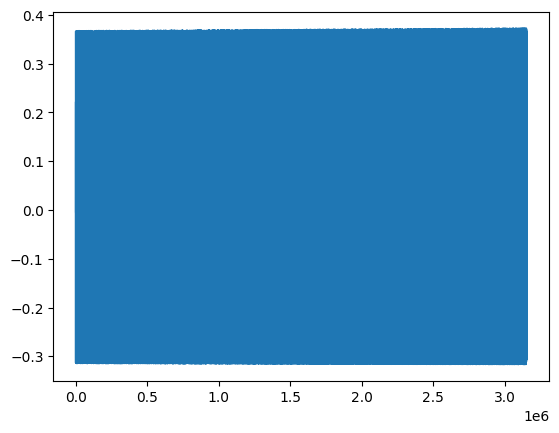

In [18]:
plt.plot(hp_gen)

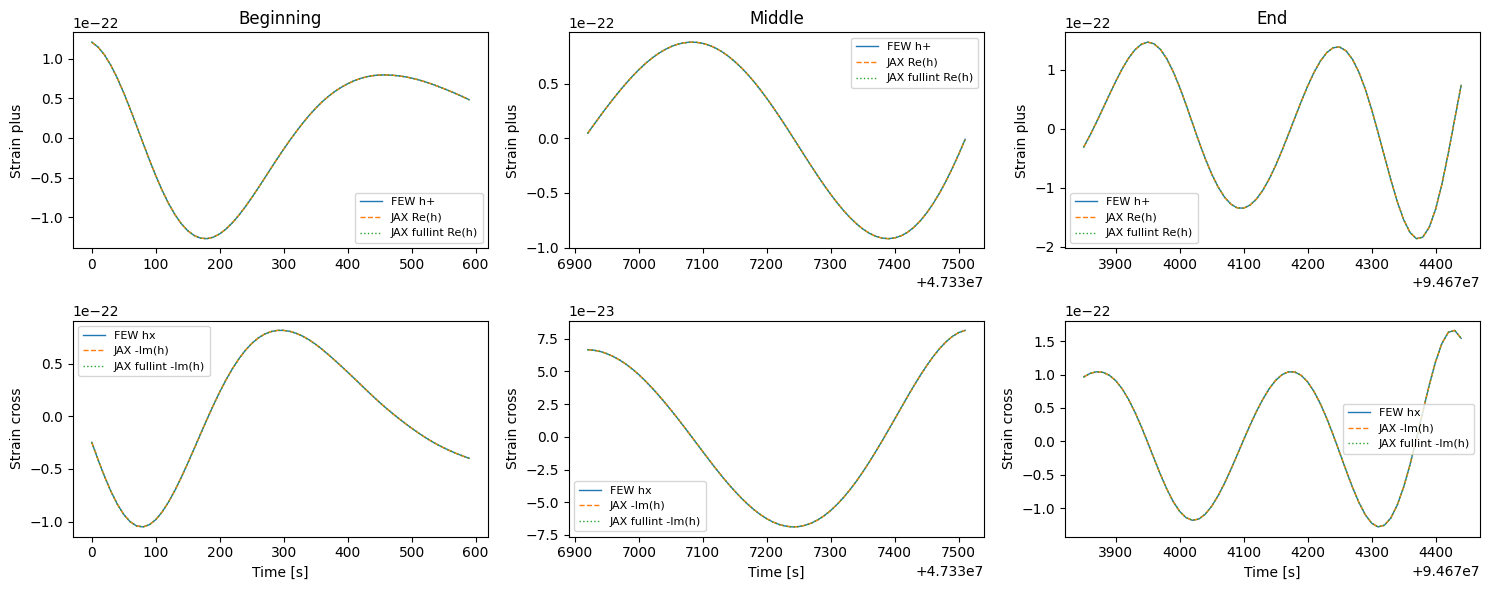

In [22]:
# Visual validation: beginning/middle/end segments of the inspiral.
# Uses a window fraction of the total duration so it adapts to any waveform length.

# Scale and align all waveforms to the same distance convention.
hp_gen_scaled = hp_gen / _scale
hc_gen_scaled = hc_gen / _scale
h_jax_dopr_scaled = h_jax_dopr / _scale

n_total = min(hp_gen.size, h_jax_scaled.size, h_jax_dopr_scaled.size)
t_total = n_total * _dt_gen

# Window selection: fraction of total samples (clamped for readability).
window_fraction = 0.02  # 2% of total duration
min_seconds = 200
max_seconds = 600
window_seconds = np.clip(window_fraction * t_total, min_seconds, max_seconds)
n_plot = int(window_seconds / _dt_gen)
n_plot = max(10, min(n_plot, n_total))

# Segment starts: beginning, middle, end.
start_begin = 0
start_middle = max(0, n_total // 2 - n_plot // 2)
start_end = max(0, n_total - n_plot)
starts = [start_begin, start_middle, start_end]
titles = ["Beginning", "Middle", "End"]

fig, ax = plt.subplots(2, 3, figsize=(15, 6), sharex=False)
for col, (start, title) in enumerate(zip(starts, titles)):
    end = start + n_plot
    t_s = np.arange(n_plot) * _dt_gen + start * _dt_gen
    ax[0, col].plot(t_s, hp_gen_scaled[start:end],            lw=1.0, label='FEW h+')
    ax[0, col].plot(t_s, -np.real(h_jax_scaled[start:end]), '--', lw=1.0, label='JAX Re(h)')
    ax[0, col].plot(t_s, -np.real(h_jax_dopr_scaled[start:end]), ':', lw=1.0, label='JAX fullint Re(h)')
    ax[0, col].set_title(title)
    ax[0, col].set_ylabel('Strain plus')
    ax[0, col].legend(fontsize=8)
    ax[1, col].plot(t_s, hc_gen_scaled[start:end],            lw=1.0, label='FEW hx')
    ax[1, col].plot(t_s, np.imag(h_jax_scaled[start:end]), '--', lw=1.0, label='JAX -Im(h)')
    ax[1, col].plot(t_s, np.imag(h_jax_dopr_scaled[start:end]), ':', lw=1.0, label='JAX fullint -Im(h)')
    ax[1, col].set_xlabel('Time [s]')
    ax[1, col].set_ylabel('Strain cross')
    ax[1, col].legend(fontsize=8)

plt.tight_layout(); plt.show()

In [28]:

# I don't know why the sign convention is the following, but... It works!
h_plus_jax  = -np.real(h_jax_scaled)
h_cross_jax = np.imag(h_jax_scaled)

h_plus_jax_dopr  = -np.real(h_jax_dopr_scaled)
h_cross_jax_dopr = np.imag(h_jax_dopr_scaled)

n_common    = min(hp_gen.size, h_plus_jax.size, h_plus_jax_dopr.size)
# FEW
hp_gen_v    = hp_gen[:n_common]
hc_gen_v    = hc_gen[:n_common]

# JAX CUBIC
h_plus_jax  = h_plus_jax[:n_common]
h_cross_jax = h_cross_jax[:n_common]

# JAX CUBIC+DOPR
h_plus_jax_dopr  = h_plus_jax_dopr[:n_common]
h_cross_jax_dopr = h_cross_jax_dopr[:n_common]

t_plot_gen  = np.linspace(0, T * YRSID_SI, n_common)

print(f'mismatch FEW-JAX CUBIC(h+) : {get_mismatch(hp_gen_v, h_plus_jax):.3e}')
print(f'mismatch FEW-JAX CUBIC(hx) : {get_mismatch(hc_gen_v, h_cross_jax):.3e}')
print(f'mismatch FEW-JAX CUBIC+DOPR(h+) : {get_mismatch(hp_gen_v, h_plus_jax_dopr):.3e}')
print(f'mismatch FEW-JAX CUBIC+DOPR(hx) : {get_mismatch(hc_gen_v, h_cross_jax_dopr):.3e}')


mismatch FEW-JAX CUBIC(h+) : 5.271e-11
mismatch FEW-JAX CUBIC(hx) : 5.396e-11
mismatch FEW-JAX CUBIC+DOPR(h+) : -2.220e-16
mismatch FEW-JAX CUBIC+DOPR(hx) : 4.441e-16


---
## Tests of the JAX Amplitude module

In [13]:
from fewtrax.amplitude import JAXAmplitudeInterpolator, AmplitudeInterpolator
from fewtrax.data.loader import load_amplitude_data, load_amplitude_data_jax

# Quick, robust test: load the JAX-ready amplitude container and evaluate the
# small test trajectory in a single vectorised call. This avoids any manual
# reshaping/shimming of the raw numpy HDF5 arrays which causes the slice errors.

# Test points (small subset) — reuse variables computed earlier in the notebook
p_test = np.asarray(p[:8])
e_test = np.asarray(e[:8])
x_test = np.full_like(e_test, x0)

# --- Mode selection via fewtrax amplitude interpolator (numpy path) ---
print("Selecting modes with fewtrax (numpy amplitude interpolator)...")
amp_data_np = load_amplitude_data(FEW_DATA_DIR)
amp_np = AmplitudeInterpolator(amp_data_np)
mode_inds = amp_np.select_modes(
    a, p_test, e_test,
    threshold=mode_selection_threshold,
    x=x0,
 )
print(f"Selected {len(mode_inds)} modes (threshold={mode_selection_threshold:.1e})")

# --- Load JAX amplitude data (optionally reduced to selected modes) ---
print("Loading JAX amplitude data (this may take a few seconds)...")
amp_data_jax = load_amplitude_data_jax(FEW_DATA_DIR, mode_indices=mode_inds)
print("Loaded JAX amplitude data. n_modes=", amp_data_jax.n_modes)

# Construct the JAX interpolator (equinox.Module) and JIT the trajectory eval
amp_jax = JAXAmplitudeInterpolator(amp_data_jax)
amp_jaxjit = jax.jit(lambda p, e: amp_jax.evaluate_trajectory(a, p, e))

# Vectorised trajectory evaluation (single jax.vmap inside evaluate_trajectory)
tic = time.perf_counter()
amps_traj = amp_jaxjit(jnp.asarray(p_test), jnp.asarray(e_test))
toc = time.perf_counter()
print(f"First JAX evaluation time: {toc - tic:.4f} seconds")

tic = time.perf_counter()
amps_traj = amp_jaxjit(jnp.asarray(p_test), jnp.asarray(e_test))
toc = time.perf_counter()
print(f"Second JAX evaluation time: {toc - tic:.4f} seconds")

# Convert once to numpy for comparison with FEW's amplitude_generator
teuk_jax_np = np.asarray(amps_traj)

# FEW reference amplitudes (same small set)
tic = time.perf_counter()
teuk_few = model.amplitude_generator(a, model.xp.asarray(p_test), model.xp.asarray(e_test), x0)
toc = time.perf_counter()
print(f"FEW amplitude_generator time: {toc - tic:.4f} seconds")
teuk_few_np = teuk_few.get() if hasattr(teuk_few, "get") else np.asarray(teuk_few)

print("FEW teuk shape:", teuk_few_np.shape)
print("JAX teuk shape:", teuk_jax_np.shape)

if teuk_few_np.ndim == 2 and teuk_jax_np.ndim == 2:
    n_t = min(teuk_few_np.shape[0], teuk_jax_np.shape[0])
    n_m = min(teuk_few_np.shape[1], teuk_jax_np.shape[1])
    few_cmp = teuk_few_np[:n_t, :n_m]
    jax_cmp = teuk_jax_np[:n_t, :n_m]
    diff = jax_cmp - few_cmp
    denom = np.linalg.norm(few_cmp)
    rel = np.linalg.norm(diff) / denom if denom > 0 else np.nan
    print(f"Relative L2 error: {rel:.3e}")
    print(f"Max |diff|:        {np.max(np.abs(diff)):.3e}")
else:
    print("Unexpected teuk dimensions; inspect outputs manually.")

Selecting modes with fewtrax (numpy amplitude interpolator)...
Selected 89 modes (threshold=1.0e-05)
Loading JAX amplitude data (this may take a few seconds)...
Loaded JAX amplitude data. n_modes= 89
First JAX evaluation time: 2.5509 seconds
Second JAX evaluation time: 0.0017 seconds
FEW amplitude_generator time: 0.0074 seconds
FEW teuk shape: (8, 6993)
JAX teuk shape: (8, 89)
Relative L2 error: 1.288e+01
Max |diff|:        2.396e-01


---
## FEW-compatible JAX mode selection (`select_modes_few`)

The earlier `AmplitudeInterpolator.select_modes` thresholds on `mean(|A|²)` per mode, which:
* ignores Ylm weighting,
* ignores the `(-m, -k, -n)` partner contribution,
* uses a per-mode floor instead of FEW's per-time cumulative cutoff,
* and runs a 6993-mode × N_traj `scipy.bisplev` Python loop (~36 s here).

`JAXAmplitudeInterpolator.select_modes_few` reproduces **FEW 2.0.0**'s `ModeSelector` exactly: builds the extended Ylm-weighted power `(N_traj, n_m + n_m_pos)`, sorts each row descending, keeps modes until per-row `cumsum < total · (1 − threshold)`, then takes the union of kept indices across all time steps and remaps the `(-m,-k,-n)` partner columns back to their `+m` positions.  All the heavy work is one jitted GPU kernel; the amplitudes computed for selection are returned so no second amplitude pass is needed.

In [8]:
from fewtrax.amplitude import JAXAmplitudeInterpolator, AmplitudeInterpolator
from fewtrax.data.loader import load_amplitude_data, load_amplitude_data_jax

In [14]:
# ---------------------------------------------------------------------------
# Test A: fewtrax JAX-native mode selection matches FEW one-to-one.
# ---------------------------------------------------------------------------
# We check the FEW-compatible selector in two stages.
#
# A.1  Feed FEW's own amplitudes (model.amplitude_generator) into
#      fewtrax's select_modes_few via the `teuk_modes=` argument.  This
#      isolates the selection algorithm — it must agree with FEW's
#      ModeSelector byte-for-byte (same power formula, same Δt-weighted
#      integral, same descending sort, same cumulative cutoff).
#
# A.2  Repeat with fewtrax's JAX amplitudes.  Any residual difference
#      is precision drift between scipy/cupy bisplev and the JAX bisplev
#      port (typically ~1e-10 relative); only modes near the cumulative
#      cutoff can flip across the threshold as a result, so we report
#      diagnostics rather than asserting.

print('Loading full JAX amplitude data (all modes)…')
amp_data_full = load_amplitude_data_jax(FEW_DATA_DIR, mode_indices=None)
amp_jax_full  = JAXAmplitudeInterpolator(amp_data_full)
print(f'Loaded {amp_data_full.n_modes} modes.')

# Per-mode Ylms (same generator and source-frame angles FEW uses internally).
l_full = np.asarray(amp_data_full.l_arr)
m_full = np.asarray(amp_data_full.m_arr)
n_full = np.asarray(amp_data_full.n_arr)
ylm_pos_full = model.ylm_gen(l_full,  m_full, theta_source, phi_source)
ylm_neg_full = model.ylm_gen(l_full, -m_full, theta_source, phi_source)
ylm_pos_full = ylm_pos_full.get() if hasattr(ylm_pos_full, 'get') else np.asarray(ylm_pos_full)
ylm_neg_full = ylm_neg_full.get() if hasattr(ylm_neg_full, 'get') else np.asarray(ylm_neg_full)

# ---------- FEW reference selection ---------------------------------------
teuk_modes_ref = model.amplitude_generator(a, model.xp.asarray(p), model.xp.asarray(e), x0)
ylms_full_ref  = model.ylm_gen(model.unique_l, model.unique_m, theta_source, phi_source)[model.inverse_lm]
x_arr = np.full_like(p, x0)
modeinds = [model.l_arr, model.m_arr, model.n_arr]
fund_freq_args = (m1, m2, a,
                  model.xp.asarray(p),
                  model.xp.asarray(e),
                  model.xp.asarray(x_arr),
                  model.xp.asarray(t))
_, _, ls_few, ms_few, ns_few = model.mode_selector(
    teuk_modes_ref, ylms_full_ref, modeinds,
    fund_freq_args=fund_freq_args,
    **mode_selector_kwargs,
)
ls_few = ls_few.get(); ms_few = ms_few.get(); ns_few = ns_few.get()
few_set = set(zip(ls_few.tolist(), ms_few.tolist(), ns_few.tolist()))
print(f'\nFEW selected {len(few_set)} modes.')

# Pull FEW amplitudes back to numpy so we can feed them into fewtrax.
teuk_few_np = teuk_modes_ref.get() if hasattr(teuk_modes_ref, 'get') else np.asarray(teuk_modes_ref)

def _summarize(name, keep_inds, teuk_all):
    fx = set(zip(
        l_full[keep_inds].tolist(),
        m_full[keep_inds].tolist(),
        n_full[keep_inds].tolist(),
    ))
    common      = few_set & fx
    only_few    = few_set - fx
    only_fewtrax = fx - few_set
    print(f'\n[{name}]')
    print(f'  fewtrax selected {len(fx)} modes  '
          f'(common={len(common)}, only-FEW={len(only_few)}, only-fewtrax={len(only_fewtrax)})')
    # If sets differ, locate the offending modes in the SORTED descending order.
    if only_few or only_fewtrax:
        # Re-compute snr2 from the same teuk_all and m_arr so we can rank.
        # FEW 2.0.0: extended power summed over all time steps;
        # the rank shown is the rank of mode j (in the original
        # m≥0 array) by total integrated extended-power.
        num_m0_local = int(np.sum(m_full == 0))
        n_m_local = m_full.size
        p_pos = np.abs(teuk_all * ylm_pos_full[None, :])**2
        teuk_partner = teuk_all[:, num_m0_local:]
        ylms_partner = ylm_neg_full[num_m0_local:]
        p_partner = np.abs(np.conj(teuk_partner) * ylms_partner[None, :])**2
        power_ext = np.concatenate([p_pos, p_partner], axis=1)
        # Sum over time, then fold partner power into the +m mode.
        psum = power_ext.sum(axis=0)
        psum_folded = psum[:n_m_local].copy()
        psum_folded[num_m0_local:] += psum[n_m_local:]
        order = np.argsort(psum_folded)[::-1]
        rank_of = {int(i): r for r, i in enumerate(order)}
        total = psum_folded.sum()
        snr2 = psum_folded
        def _show(tag, lmns):
            print(f'  --- {tag} ({len(lmns)}):')
            for (l, m, n) in sorted(lmns):
                # find the linear index in l_full/m_full/n_full
                idx = int(np.where(
                    (l_full == l) & (m_full == m) & (n_full == n)
                )[0][0])
                r = rank_of.get(idx, -1)
                frac = snr2[idx] / total if total > 0 else 0.0
                print(f'      (l={l:2d}, m={m:3d}, n={n:3d})  rank={r:4d}  '
                      f'snr2/total={frac:.3e}')
        if only_few:      _show('present in FEW only',     only_few)
        if only_fewtrax:  _show('present in fewtrax only', only_fewtrax)

# ---------- A.1: FEW amplitudes through fewtrax selector ------------------
tic = time.perf_counter()
keep_inds_few, _ = amp_jax_full.select_modes_few(
    a, p, e, ylm_pos_full, ylm_neg_full,
    threshold=mode_selection_threshold,
    teuk_modes=teuk_few_np,             # bypass JAX amp pass
)
t_A1 = time.perf_counter() - tic
print(f'\nA.1  FEW amplitudes → fewtrax selector  : {t_A1*1000:6.1f} ms (1st call, JIT)')
_summarize('A.1  selection logic only', keep_inds_few, teuk_few_np)

# ---------- A.2: all-JAX path --------------------------------------------
tic = time.perf_counter()
keep_inds_jax, teuk_all_jax = amp_jax_full.select_modes_few(
    a, p, e, ylm_pos_full, ylm_neg_full,
    threshold=mode_selection_threshold,
)
t_A2 = time.perf_counter() - tic
print(f'\nA.2  fewtrax JAX amp + selector (1st call): {t_A2*1000:6.1f} ms')
_summarize('A.2  all-JAX', keep_inds_jax, teuk_all_jax)

# Amplitude precision: how close is the JAX bisplev port to FEW's bisplev?
diff = teuk_all_jax - teuk_few_np
abs_diff = np.abs(diff)
rel = abs_diff / (np.abs(teuk_few_np) + 1e-30)
print(f'\namplitude port precision (JAX vs FEW)')
print(f'  max |Δ|             : {abs_diff.max():.3e}')
print(f'  max relative        : {rel.max():.3e}')
print(f'  median |Δ|/|FEW|    : {np.median(rel):.3e}')

# Strict pass condition: A.1 must match FEW byte-for-byte.
fx_set_few = set(zip(
    l_full[keep_inds_few].tolist(),
    m_full[keep_inds_few].tolist(),
    n_full[keep_inds_few].tolist(),
))
assert fx_set_few == few_set, 'Selection algorithm mismatch (A.1 should be byte-exact).'
print('\nPASSED A.1: selection algorithm matches FEW exactly (given FEW amplitudes).')


Loading full JAX amplitude data (all modes)…
Loaded 6993 modes.

FEW selected 153 modes.

A.1  FEW amplitudes → fewtrax selector  :    5.5 ms (1st call, JIT)

[A.1  selection logic only]
  fewtrax selected 153 modes  (common=153, only-FEW=0, only-fewtrax=0)

A.2  fewtrax JAX amp + selector (1st call):   75.5 ms

[A.2  all-JAX]
  fewtrax selected 153 modes  (common=153, only-FEW=0, only-fewtrax=0)

amplitude port precision (JAX vs FEW)
  max |Δ|             : 1.988e-05
  max relative        : 1.517e+00
  median |Δ|/|FEW|    : 3.284e-04

PASSED A.1: selection algorithm matches FEW exactly (given FEW amplitudes).


In [15]:
# ---------------------------------------------------------------------------
# Test B: timing.  numpy AmplitudeInterpolator.select_modes (the path used
# in cell b8999bf5)  vs  the JAX-native select_modes_few.
# ---------------------------------------------------------------------------
tic = time.perf_counter()
mode_inds_np = amp_np.select_modes(
    a, np.asarray(p), np.asarray(e),
    threshold=mode_selection_threshold, x=x0,
)
t_np = time.perf_counter() - tic
print(f'numpy AmplitudeInterpolator.select_modes : {t_np:8.3f} s   (n_modes={len(mode_inds_np)})')

# warm-up was done in Test A, so this call only pays for execution.
tic = time.perf_counter()
keep_inds_jax2, _ = amp_jax_full.select_modes_few(
    a, p, e, ylm_pos_full, ylm_neg_full,
    threshold=mode_selection_threshold,
)
t_jax = time.perf_counter() - tic
print(f'fewtrax JAX select_modes_few (warm)      : {t_jax:8.3f} s   (n_modes={len(keep_inds_jax2)})')
if t_jax > 0:
    print(f'speed-up                                 : {t_np / t_jax:8.1f}×')


numpy AmplitudeInterpolator.select_modes :   10.538 s   (n_modes=86)
fewtrax JAX select_modes_few (warm)      :    0.009 s   (n_modes=153)
speed-up                                 :   1231.3×


In [ ]:
# ---------------------------------------------------------------------------
# Test C: full waveform built with the FEW-matched fewtrax mode set.
# Mismatch vs GenerateEMRIWaveform should be at the same ~1e-11 level as the
# FEW-modes JAX waveform in cell b0a36a29 (since the mode lists now agree).
# ---------------------------------------------------------------------------
_scale = dist * Gpc / (m2 * MRSUN_SI)  # convert to dimensionless strain at 1 Gpc

teuk_sel  = jnp.asarray(teuk_all_jax[:, keep_inds_jax])
ls_sel    = jnp.asarray(l_full[keep_inds_jax])
ms_sel    = jnp.asarray(m_full[keep_inds_jax])
ns_sel    = jnp.asarray(n_full[keep_inds_jax])
ks_sel    = jnp.zeros_like(ls_sel)
ylms_sel  = jnp.concatenate([
    jnp.asarray(ylm_pos_full[keep_inds_jax]),
    jnp.asarray(ylm_neg_full[keep_inds_jax]),
])

dt_local = 10.0
n_pts    = int((t[-1] - t[0]) / dt_local) + 1
t_dense_local = t[0] + dt_local * np.arange(n_pts)

tic = time.perf_counter()
h_jax_fxsel = Interp_and_modesum_WFbuilder(
    t, teuk_sel, ylms_sel, ls_sel, ms_sel, ks_sel, ns_sel,
    Phi_phi_tr=Phi_phi, Phi_theta_tr=Phi_theta, Phi_r_tr=Phi_r,
    t_dense=t_dense_local,
    sum_batch_size=100,
)
print(f'WFbuilder (FEW-matched fewtrax modes) : {time.perf_counter()-tic:.3f} s   '
      f'(n_modes={teuk_sel.shape[1]}, n_t_dense={n_pts})')

h_jax_fxsel_scaled = h_jax_fxsel / _scale
h_plus_fx  = -np.real(h_jax_fxsel_scaled)
h_cross_fx =  np.imag(h_jax_fxsel_scaled)

n_common_t = min(hp_gen.size, h_plus_fx.size)
print(f'mismatch FEW vs fewtrax(JAX-sel)(h+) : '
      f'{get_mismatch(hp_gen[:n_common_t], h_plus_fx[:n_common_t]):.3e}')
print(f'mismatch FEW vs fewtrax(JAX-sel)(hx) : '
      f'{get_mismatch(hc_gen[:n_common_t], h_cross_fx[:n_common_t]):.3e}')


WFbuilder (FEW-matched fewtrax modes) : 0.040 s   (n_modes=153, n_t_dense=3155815)
mismatch FEW vs fewtrax(JAX-sel)(h+) : 8.315e-10
mismatch FEW vs fewtrax(JAX-sel)(hx) : 8.597e-10
